# Imports

First, import the network generation and analysis modules.

In [1]:
# include file where structure analysis modules are stored
include("structure_analysis_modules.jl")

# import my module that contains all functions for the generation and analysis of networks
import .NetworkGeneration as NG
import .NetworkAnalysis as NA
import .GeneralUtilities as GU

import Plots
import MetaGraphsNext

# Network generation

## Basics
We start by generating a `MetaGraph` object, which will contain all the information about our spatial network. The `evolution_dict` includes essential details on the initial network and its evolution, as well as the strain energy. The equilibrium angle $\theta_\text{eqm}$ is set here. A range of crystalline initial networks is currently implemented, which can be found on the [RCSR database](http://rcsr.net/nets ): **dia** (diamond), **srs** (gyroid), **lcs**, **ctn**, and **pto**. Furthermore, modified versions of the **pto**, **bcu**, and **pcu** are implemented.

In [2]:
evolution_dict = NA.get_evolution_dict(;nr_vertices = 216, network_type="dia", bond_bending_const=0.1, min_ring_size=3, theta_ground_state=180.0)
spatial_network = NG.get_periodic_network(evolution_dict)

nr of edges in unitcell should be 16=?=16.0
CN_all=216=?=CN4=216


Meta graph based on a Graphs.SimpleGraphs.SimpleGraph{Int64} with vertex labels of type Int64, vertex metadata of type Dict{String, Any}, edge metadata of type Dict{String, Union{Float64, Vector{Float64}}}, graph metadata given by Dict{String, Any}("bond_bending_const" => 0.1, "total_energy_up_to_date" => true, "supercell_edge_length" => 6.9282032302755105, "nr_dimensions" => 3, "theta_ground_state" => 180.0, "nr_vertices" => 216, "total_energy" => 21.600000000000037), and default weight 1.0

We can visualize the initial network.

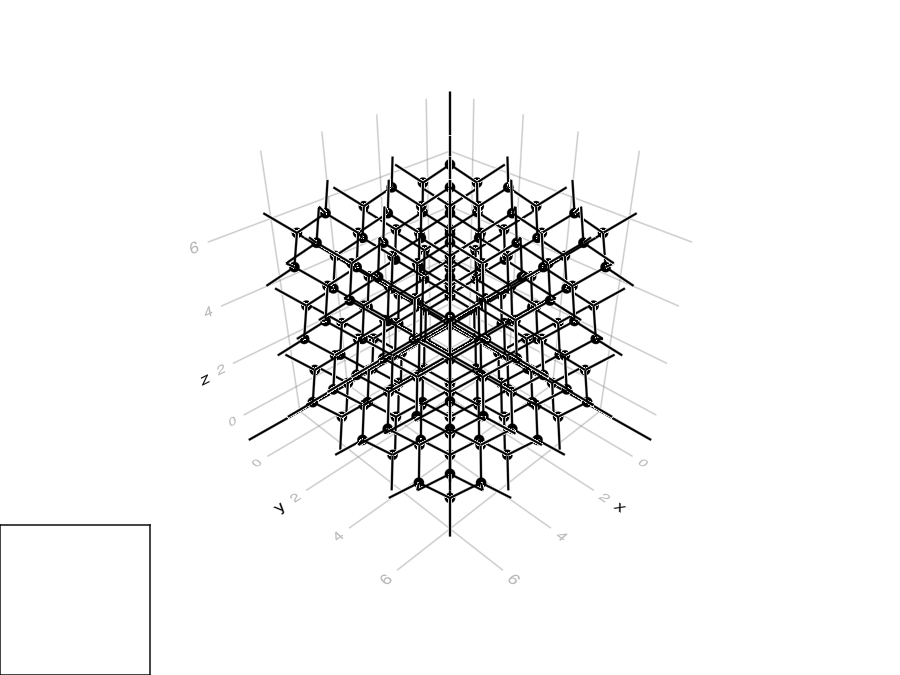

In [3]:
NG.plot_spatial_network(spatial_network)

The network properties, such as the number of vertices and the total Keating energy, are stored as a dictionary and can be accessed as follows.

In [4]:
spatial_network[]

Dict{String, Any} with 7 entries:
  "bond_bending_const"      => 0.1
  "total_energy_up_to_date" => true
  "supercell_edge_length"   => 6.9282
  "nr_dimensions"           => 3
  "theta_ground_state"      => 180.0
  "nr_vertices"             => 216
  "total_energy"            => 21.6

Furthermore, information about its vertices (or nodes) and bonds (or edges) can be accessed.

In [5]:
println(spatial_network[1])
println(collect(MetaGraphsNext.neighbor_labels(spatial_network, 1)))
println(spatial_network[1,2])

Dict{String, Any}("coordination_nr" => 4, "position" => [4.330127018922194, 6.6395280956806975, 4.330127018922194])
[2, 95, 127, 160]
Dict{String, Union{Float64, Vector{Float64}}}("vector" => [-0.5773502691896257, -0.5773502691896262, 0.5773502691896262], "distance_squared" => 1.0)


For more details, refer to the [MetaGraphsNext documentation]( https://juliagraphs.org/MetaGraphsNext.jl/stable/ ).

Now, we can perform a _Monte Carlo move_ which consists of switching a bond, relaxing the network according to the Keating strain energy with the equilibrium angle $\theta_\text{eqm}$ set above, and accepting/rejecting the move. The temperature $T$ controls the probability that a bond switch will be accepted. At $T=0$, only a decrease in total Keating energy is allowed. Since we start from the ground state, a decrease in energy is not possible initially. We choose a high temperature that favors an increase in energy.

Move accepted: true


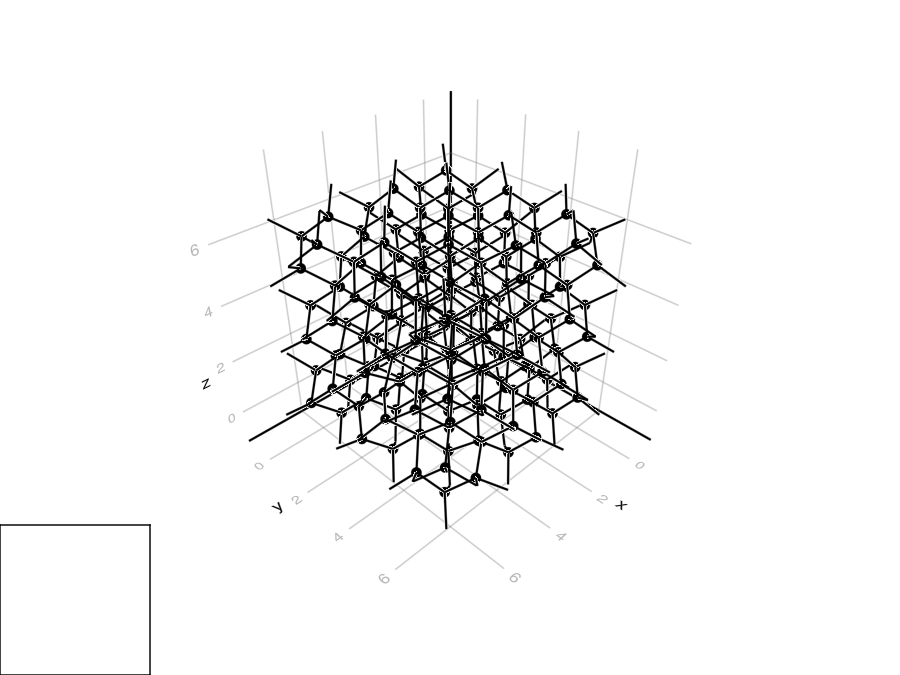

In [6]:
temperature = 10

spatial_network, move_accepted = NG.monte_carlo_move!(
    spatial_network, 
    evolution_dict,
    temperature)

println("Move accepted: ", move_accepted)
NG.plot_spatial_network(spatial_network)

We can evolve the network for a given number of Monte Carlo moves.

Thread 1: attempted bond
                                switch nr 10 at T=10 accepted. T=10 is 
                                100.000 % done. Finished quenches: 0


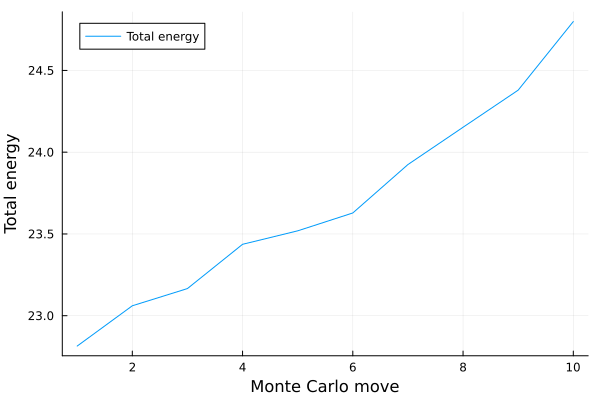

In [7]:
nr_attempted_bond_switches = 10

spatial_network, total_energy_vec, move_accepted_vec = NG.evolve_network!(
    spatial_network,
    evolution_dict,
    nr_attempted_bond_switches, 
    temperature;
    print_progress = true,
    print_every_nr_attempted_bond_switches = 10)

Plots.plot(total_energy_vec, xlabel="Monte Carlo move", ylabel="Total energy", label="Total energy")

Visualizing the network again illustrates how a series of bond switches distorts the initially crystalline network.

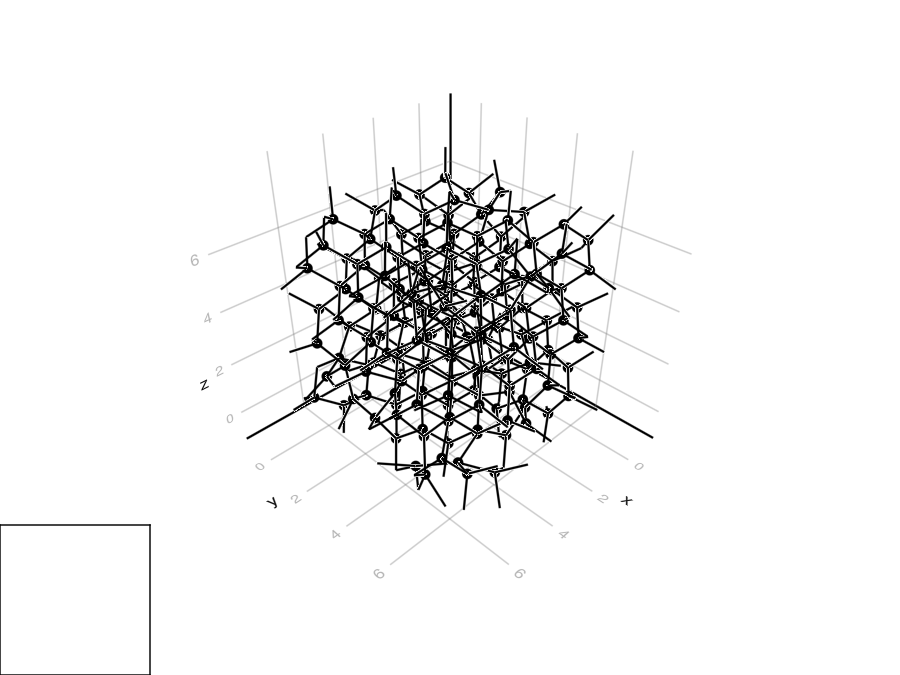

In [8]:
NG.plot_spatial_network(spatial_network)

We find that a sequence of heating at constant gradient, followed by cooling at the same gradient and a quench at $T=0$, yields reasonable control over the introduced disorder. The network is quenched until no single bond switch can further reduce the total energy. One _Monte Carlo step_ is defined as the number of Monte Carlo moves, where, on average, every bond chain is attempted once. The number of available bond chains is estimated from the number of vertices $N_\mathrm{vertices}$ and the mean coordination number $\overline{Z}$: There are $N_\mathrm{vertices}$ choices for the first vertex of the chain, $\overline{Z}$ for the second vertex connected to the first one, and $\overline{Z}-1$ options for vertices 3 and 4, respectively. Since the order of the chain is not relevant, we divide by a factor of 2 and obtain the number of chains $N_\mathrm{chains}=N_\mathrm{vertices} \cdot \overline{Z} \cdot (\overline{Z}-1)^2/2$. To demonstrate the temperature profile, we choose a very steep gradient of 10 temperature units per Monte Carlo step. The argument `nr_monte_carlo_steps_per_temperature` sets the resolution, which determines how finely the temperature should be increased. A default value of $0.01$ typically works well.

In [9]:
maximal_temperature = 0.1

temperature_vec, nr_monte_carlo_steps_per_temperature_vec = NA.get_temperature_sequence_heating_cooling_gradient(maximal_temperature;
            temperature_gradient = 10.0, 
            nr_monte_carlo_steps_per_temperature = 0.01,
            quench = false )

length(temperature_vec)

3

In [10]:
evolution_dict["temperature_vec"] = temperature_vec
evolution_dict["nr_monte_carlo_steps_per_temperature_vec"] = nr_monte_carlo_steps_per_temperature_vec

spatial_network, total_energy_vec, move_accepted_vec = NG.evolve_network_temperature_sequence!(
    spatial_network,
    evolution_dict;
    total_energy_vec = total_energy_vec,
    move_accepted_vec= move_accepted_vec,
    print_progress = true,
    print_every_nr_attempted_bond_switches = 100)

T=0.0 done
T=0.1 done
T=0.0 done


3-element Vector{Any}:
 Meta graph based on a Graphs.SimpleGraphs.SimpleGraph{Int64} with vertex labels of type Int64, vertex metadata of type Dict{String, Any}, edge metadata of type Dict{String, Union{Float64, Vector{Float64}}}, graph metadata given by Dict{String, Any}("bond_bending_const" => 0.1, "total_energy_up_to_date" => true, "supercell_edge_length" => 6.9282032302755105, "nr_dimensions" => 3, "theta_ground_state" => 180.0, "nr_vertices" => 216, "total_energy" => 25.932981214412347), and default weight 1.0
 [22.81442376229721, 23.06084463711483, 23.166049462409937, 23.436757856294378, 23.519143417411243, 23.62845344135226, 23.924576776939563, 24.152617536254464, 24.37963137826216, 24.799024645154276  …  25.932981214412347, 25.932981214412347, 25.932981214412347, 25.932981214412347, 25.932981214412347, 25.932981214412347, 25.932981214412347, 25.932981214412347, 25.932981214412347, 25.932981214412347]
 Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

We save the generated network to a GML file, which can, for example, be loaded by Python's `Networkx` package.

In [11]:
save_path = "../data/structures/example_networks/single_network/"
filename = "example_network"

NG.save_spatial_network_to_gml(
    spatial_network,
    filename;
    evolution_dict = evolution_dict,
    save_path = save_path)

Loading the network and the evolution dictionary works as follows.

In [12]:
spatial_network = NG.load_spatial_network_from_gml(save_path*filename*".gml")
evolution_dict = GU.load_h5_dict(save_path*filename*"_evolution.h5")

Dict{String, Any} with 21 entries:
  "bond_bending_const"                       => 0.1
  "nr_max_relaxation_cycles"                 => 25
  "nr_monte_carlo_steps_per_temperature_vec" => [0.01, 0.01, 0.01]
  "temperature_vec"                          => [0.0, 0.1, 0.0]
  "theta_ground_state"                       => 180.0
  "inefficient_optimization_method"          => "newton"
  "estimated_nr_bond_switches"               => 77760
  "nr_vertices"                              => 216
  "reject_during_relaxation_cycle_threshold" => 5
  "thermal_fluctuations"                     => false
  "min_ring_size"                            => 3
  "mean_nr_monte_carlo_steps_for_quenching"  => 13.7
  "shell_nr"                                 => 4
  "relax_efficiently"                        => true
  "break_at_relative_cluster_energy_change"  => 0.0001
  "nr_dimensions"                            => 3
  "network_type"                             => "dia"
  "relaxation_optimization_parameter_l"      

The vertices and bonds in the spatial network are connected via periodic boundary conditions. If we want to plot the network or run an optical simulation with it, we need to transform the network by adding virtual vertices outside the supercell and connecting the vertices close to the cell edges to those virtual vertices. Furthermore, if a bond is located near the edge and we want to assign a cylinder volume to it, we need to duplicate the bond on the other side of the supercell, just outside the simulation box. These actions are performed using the following function.

In [13]:
spatial_network = NG.get_spatial_network_for_simulation!(
    spatial_network;
    vector_out_of_supercell_length = 1,
    duplicate_bonds_close_to_supercell_edge = true,
    save_result = true,
    filename = filename,
    save_path = save_path)

Meta graph based on a Graphs.SimpleGraphs.SimpleGraph{Int64} with vertex labels of type Int64, vertex metadata of type Dict{String, Any}, edge metadata of type Dict{String, Any}, graph metadata given by Dict{String, Any}("bond_bending_const" => 0.1, "total_energy_up_to_date" => true, "supercell_edge_length" => 6.9282032302755105, "nr_dimensions" => 3, "theta_ground_state" => 180.0, "nr_vertices" => 1566, "total_energy" => 25.932981214412347), and default weight 1.0

In [14]:
spatial_network[]

Dict{String, Any} with 7 entries:
  "bond_bending_const"      => 0.1
  "total_energy_up_to_date" => true
  "supercell_edge_length"   => 6.9282
  "nr_dimensions"           => 3
  "theta_ground_state"      => 180.0
  "nr_vertices"             => 1566
  "total_energy"            => 25.933

In case we want to export a given network as a file that can be handled by Blender or another rendering software, we can create cylinder meshes for all bonds. For this, we need to set a radius which is passed in units of the equilibrium bond length $d$.

In [15]:
NG.save_mesh_from_spatial_network(
    spatial_network, 
    filename;
    bond_radius = 0.35,
    vector_out_of_supercell_length = 1,
    save_path = save_path,
    duplicate_bonds_close_to_supercell_edge = true,
    format = "obj")

## Parallel network generation

Two functions are implemented to generate networks in parallel on multiple threads. For this, we first need to create the evolution dictionaries of various networks and save them locally.

In [16]:
maximal_temperatures = [0.11, 0.12]
temperature_gradient = 0.1
nr_vertices = 216
bond_bending_const = 0.1
theta_ground_state = 180.0
evolution_dicts_path = "../data/structures/example_networks/many_networks/evolution_dicts/"

for maximal_temperature in maximal_temperatures
    temperature_vec, nr_monte_carlo_steps_per_temperature_vec = NA.get_temperature_sequence_heating_cooling_gradient(
        maximal_temperature;
        temperature_gradient = 10.0, 
        nr_monte_carlo_steps_per_temperature = 0.1,
        quench = false )
    evolution_dict = NA.get_evolution_dict(;nr_vertices = nr_vertices ,temperature_vec = temperature_vec,
        nr_monte_carlo_steps_per_temperature_vec = nr_monte_carlo_steps_per_temperature_vec, min_ring_size = 3,
        bond_bending_const = bond_bending_const, theta_ground_state = theta_ground_state)
    filename = string(nr_vertices)*"_vertices_T_"*string(maximal_temperature)*"_heat_cool_"*string(temperature_gradient)*"_per_mc"
    GU.save_dict_to_h5(evolution_dict, evolution_dicts_path*filename*"_evolution.h5")
end

To generate networks in parallel, we need to run Julia in multi-threaded mode. E.g., to run two threads in parallel, use the Linux command `\$ julia --threads 2`. More information about multi-threading in Julia is available [here](https://docs.julialang.org/en/v1/manual/mulE.g.ti-threading/). 

To evolve one network for each evolution dictionary, we can use the following function. The combination of the arguments `save_network_after_each_temperature` and `further_evolve_previous_networks` can be used to save checkpoint networks after each temperature and further evolve from the last saved network. The print lock is necessary so that multiple threads can print their individual progress one after another.

In [17]:
save_path = "../data/structures/example_networks/many_networks/"
NG.generate_spatial_networks_from_evolution_dicts_in_directory(
        evolution_dicts_path,
        save_path;
        print_every_nr_attempted_bond_switches = 10,
        print_progress = true,
        save_network_after_each_temperature = false,
        further_evolve_previous_networks = false,
        print_lock = Threads.ReentrantLock())


Thread 1 is evolving file 216_vertices_T_0.11_heat_cool_0.1_per_mc_evolution.h5
nr of edges in unitcell should be 16=?=16.0
CN_all=216=?=CN4=216
Thread 1: attempted bond 
                                switch nr 10 at T=0.0 declined. T=0.0 is 
                                2.571 % done. Finished quenches: 0

To evolve several networks for each evolution dictionary, we use the following function. Due to the random sampling inherent to any Monte Carlo method, the networks will evolve under the same conditions and temperature profile, but with a different sequence of bond switches, and will therefore yield different outcomes. Note that this function is only implemented for Linux!

In [18]:
if(Sys.islinux())
    NG.generate_spatial_networks_from_evolution_dicts_in_directory_multiple_runs(
        evolution_dicts_path,
        save_path;
        print_every_nr_attempted_bond_switches = 10,
        print_progress = true,
        save_network_after_each_temperature = false,
        further_evolve_previous_networks = false,
        print_lock = Threads.ReentrantLock(),
        runs_vec = collect(1:2))
end

# Network analysis
In the function `get_all_dicts_from_network_single_file`, a list of functions and order metrics is implemented to characterize spatial networks. This command may take a few minutes to finish.

In [18]:
filename = "example_network"
spatial_network_path = "../data/structures/example_networks/single_network/"
analysis_data_path = "../data/analysis_data/example_networks/single_network/"
digital_sphere_mask_path = "../data/analysis_data/digital_sphere_masks/"

NA.get_all_dicts_from_network_single_file(
    filename,
    spatial_network_path,
    analysis_data_path;
    digital_sphere_mask_path = digital_sphere_mask_path,
    pore_size_sampling_grid_size = 0.2,
    max_pore_radius = 3.0,
    periodic_boundary_conditions = true,
    print_progress = true,
    print_lock = Threads.ReentrantLock())


Thread Structure factor calculation for 1vertices: attempted bond 
                                switch nr  
                    thread nr 201 at T=: 0.05 declined. T=.0.05 is 
                                 %5
.Structure factor calculation for 1vertices4 
                    thread nr 11 % done. Finished quenches: : 01
1Thread .10: attempted bond 
                                switch nr  %30
 at T=Structure factor calculation for 0.0vertices declined. T= 
                    thread nr 0.01 is 
                                : 71.67.152 % % done. Finished quenches: 
0Structure factor calculation for 
verticesThread  
                    thread nr 11: attempted bond 
                                switch nr : 402 at T=20.0. declined. T=00.0 % is 
                                
1Structure factor calculation for 0vertices. 
                    thread nr 218: 32 % done. Finished quenches: 70.
6Thread  %1
: attempted bond 
                                switch nr Structure facto

You might have noticed that the calculation of some metrics is quite computationally expensive. It is therefore favorable to analyze multiple networks in parallel. As explained above, for this, julia can be run in multi-threaded mode. This command only runs on Linux.

In [21]:
if(Sys.islinux())
    NA.get_all_dicts_from_networks_multithreading(
        spatial_network_path,
        analysis_data_path;
        digital_sphere_mask_path = digital_sphere_mask_path,
        pore_size_sampling_grid_size = 0.2,
        max_pore_radius = 3.0,
        periodic_boundary_conditions = true,
        print_progress = true,
        print_lock = Threads.ReentrantLock()
        runs_vec = collect(1:2))
end

Once all networks are analyzed, we can create one dictionary containing the order metric values of all analyzed networks.